<img src="https://github.com/GJay99/Trabajos_APS/blob/master/TS0/logo_UNSAM.jpg?raw=1" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Gonzalo Jay

# Introducción
En este segundo trabajo semanal, realizamos experimentos analizando la transformada rápida de Fourier de distintas señales, además de aprender a como ajustar su potencia a valores deseados y como graficar en dB tomando como 0dB la potencia de nuestra primer senoidal de 1W.
Esto lo pudimos hacer gracias a distintas funciones incluidas en las librerías Numpy y Scipy.

En cuanto a realizar la FFT utilizamos scipy.fft la cual incluye un método para realizar la FFT y otro para entregarnos el eje de frecuencias correspondiente a esos valores.

Para la mayoría de funciones nos apoyamos en el hecho de que si las mismas tienen media cero podemos decir que:
\begin{equation}
Var_{x[n]}=Pot_{x[n]}=np.var(x)
\end{equation}
Aunque ya veremos en el desarrollo que esto no es valido para todas las funciones.

# Resolución
Primero, realizamos la importación de todas las librerías que serán necesarias y añadimos el número de muestras (N) el cuál mantendremos constante a lo largo de todo el código.

In [1]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
N = 1000    # Muestras

También, incluimos la función mi_funcion_seno. Está función la generamos en el TS0, y la usaremos de soporte para crear las senoidales que analizaremos durante este trabajo. 

In [3]:
def mi_funcion_seno(vmax = 1, dc = 0, ff = 1, ph = 0, nn = N, fs = 1000):
    tt=np.zeros(nn)
    xx=np.zeros(nn)
    for n in np.arange(0,nn,1):
        tt[n]= n * (1/fs)
        xx[n]= vmax * np.sin(2*np.pi*ff * tt[n] + ph) + dc
    return tt, xx

## Análisis seno con 2kHz de frecuencia, potencia de 1W y 10 muestras por periodo
La primer señal que analizaremos se trata de un seno el cuál se nos a pedido que tenga una frecuencia de 2 kHz y al menos 10 muestras por periodo. Tomaremos ese valor como nuestro N o periodo muestral.

Sabemos que para que una función sea periódica en el tiempo se debe cumplir que:
\begin{equation}
x_{(t)}=x_{(t+T)}=>sin(\omega * t) = sin(\omega * t + \omega * T)=>\omega * T = 2*k*\pi
\end{equation}
Si ahora discretizamos esto tendremos que:
\begin{equation}
T =  \frac{N}{f_s} \land \omega = 2*\pi*ff => \omega * T = 2*\pi*ff*\frac{N}{f_s}=2*k*\pi =>ff*\frac{N}{f_s} = k
\end{equation}
Donde $ff$ es la frecuencia de la señal, $f_s$ es la frecuencia de muestreo, $k$ una constante real y $N$, como ya dijimos, el periodo muestral. Previamente, fijamos que $N=10$ y $ff=2000 Hz$, por lo cuál debemos despejar $f_s$.
\begin{equation}
ff*\frac{N}{f_s} = k => f_s = \frac{ff * N}{k}
\end{equation}
Por último, tomado $k=1$ obtendremos:
\begin{equation}
f_s = \frac{ff * N}{k}=2000 Hz * 10 = 20kHz
\end{equation}
Entonces volcamos estos valores de $ff$, $f_s$ y $N$ a nuestro programa. Para verifica que hallamos tomado bien el valor de $f_s$, graficamos el seno pero únicamente en las primeras once muestras. Como se puede ver en la figura, las muestras correspondientes a x[0] y x[10] caen a la misma altura, demostrando que los primeros 10 puntos correspondientes a valores entre x[0] y x[9] pertencen efectivamente al primer periodo de la señal.

Por otro lado para lograr la potencia deseada debemos revisar la definición de potencia para una señal periódica:
\begin{equation}
P = \frac{1}{N} * \sum_{k=0}^{N-1} |x_{[k]}|^2
\end{equation}
Entonces, si $x$ es una senoide tendremos que:
\begin{equation}
P = \frac{A^2}{2} => A = \sqrt{2*P} = \sqrt{2}
\end{equation}

1.0000000000000007


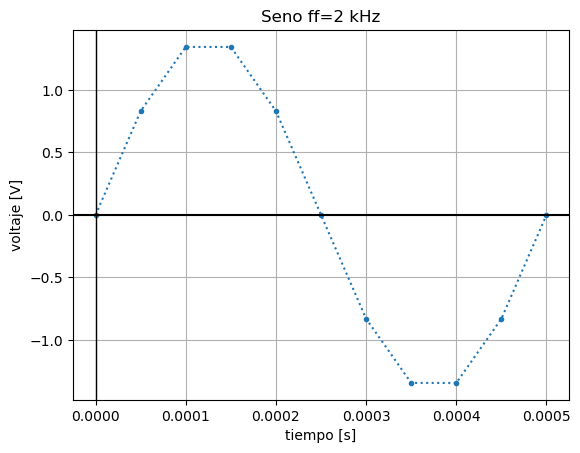

In [4]:
fs = 20000
t1,x1 = mi_funcion_seno(vmax=np.sqrt(2),ff=2000,fs=fs)

pot_x1=np.var(x1)
print(pot_x1)
    
plt.figure(1)
plt.plot(t1[:11], x1[:11], ":.")
plt.title("Seno ff=2 kHz")
plt.xlabel("tiempo [s]")
plt.ylabel("voltaje [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

También calculamos la potencia de la señal con la aproximación de que $P_{(x)} = Var_{(x)}$ para comprobar que la misma sea aproximadamente de 1W, lo cual se cumple.

Ahora analizaremos su transformada de Fourier aplicando FFT y graficando el modulo de la transformada en dB en función a la frecuencia. Para que la referencia de 0dB quede en base a la potencia de esta señal, simplemente tomamos como referencia la amplitud máxima absoluta de su FFT  y para todos los futuros valores de amplitud de cualquier señal únicamente deberemos calcular:
\begin{equation}
|X|_{dB} = 20 * log_{10}(\frac{|X|_{(ff)}}{X_{ref}})
\end{equation}

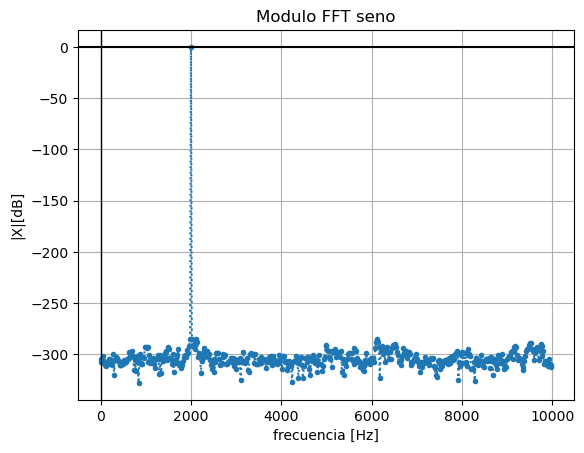

In [5]:
x1_fft = fft(x1)
x1_fft = x1_fft[:N//2]

freq = fftfreq(N,1/fs)
freq = freq[:N//2]

x1_fft_abs = np.abs(x1_fft)
ref = np.max(x1_fft_abs)
x1_fft_db = 20 * np.log10(x1_fft_abs / ref)

plt.figure(2)
plt.plot(freq,x1_fft_db,":.")
plt.title("Modulo FFT seno")
plt.ylabel("|X|[dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Podemos ver que sucede lo esperado en este tipo de señales. Al tomar el módulo de la FFT de un seno se espera ver dos $\delta$ ubicados $ff$ y $-ff$, que por simetría también pueden ser hallados en $ff$ y $fs-ff$, aunque por facilidad gráfica decidimos graficar solo la primer mitad de las frecuencias por comodidad gráfica.

Retomando. Vemos como efectivamente a los 2kHz tenemos una delta perfecta de 0dB, es decir, 1W. Esta delta es tan clara y no presenta fuga espectral gracias a que tomamos $f_s$ como un multiplo entero de $ff$.

In [6]:
print(x1_fft_db[freq==2000])

[0.]


## Análisis seno desfasado y con potencia de 2W.
Para esta segunda señal se repetirá el mismo $f_s$ y $ff$ de la anterior, pero debemos tomar en cuenta el cambio de fase y de amplitud.
Para la fase es fácil notar que únicamente debemos hacer que $\phi = \frac{\pi}{2}$. Además, usaremos la misma fórmula para encontrar la amplitud necesaria para conseguir la potencia deseada, pero dejando que python la calcule.

In [7]:
pot_deseada = 2
vmax = np.sqrt(2*pot_deseada)

t2,x2 = mi_funcion_seno(vmax=vmax,ff=2000,ph=np.pi/2,fs=fs)

pot_x2 = np.var(x2)
print(pot_x2)

1.9999999999999991


Con esto confirmamos haber conseguido una potencia de aproximadamente 2W y procedemos a graficar la señal para volver a comprobar que efectivamente contemos con 10 puntos por periodo y el desfasaje deseado.

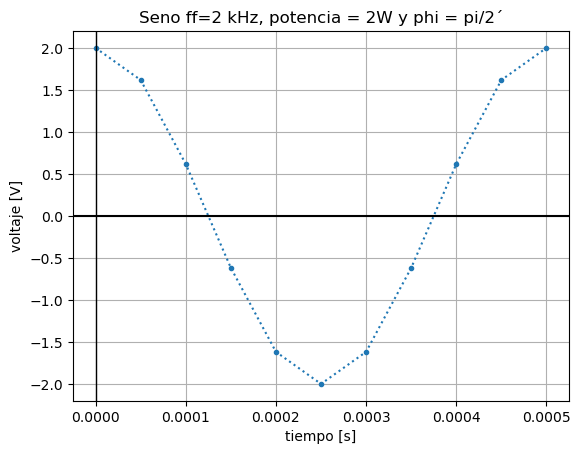

In [8]:
plt.figure(3)
plt.plot(t2[:11], x2[:11], ":.")
plt.title("Seno ff=2 kHz, potencia = 2W y phi = pi/2´")
plt.xlabel("tiempo [s]")
plt.ylabel("voltaje [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Procedemos a aplicar la FFT y normalizarlo utilizando el valor de referencia previamente calculado.

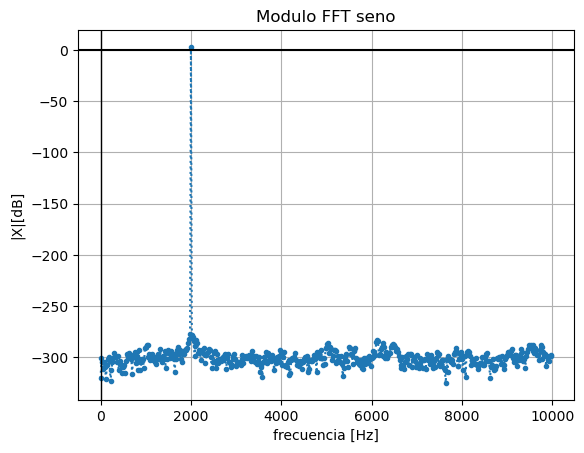

In [9]:
x2_fft = fft(x2)
x2_fft = x2_fft[:N//2]

x2_fft_abs = np.abs(x2_fft)
x2_fft_db = 20 * np.log10(x2_fft_abs / ref)

plt.figure(4)
plt.plot(freq,x2_fft_db,":.")
plt.title("Modulo FFT seno")
plt.ylabel("|X|[dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

In [10]:
print(x2_fft_db[freq==2000])

[3.01029996]


Con esto podemos visualizar como la potencia de la señal modifica su FFT. Si queremos verificar que nuestro valor en dB es compatible con lo esperado debemos realizar un sencillo despeje(solo posible al tratarse de una senoidal):
\begin{equation}
|X|_{dB} = 10 * \log_{10}(\frac{P_{|X|_{(ff)}}}{1W})\Rightarrow P_{|X|_{(ff)}} = 1W * 10^{\frac{|X|_{dB}}{10}}
\end{equation}
Entonces, reemplazando por lo obtenido:
\begin{equation}
P_{|X|_{(2000)}} = 1W * 10^{\frac{3.01029996}{10}} = 1W * 2 = 2W
\end{equation}
Por lo cual, esta FFT nos está mostrando una $\delta$ a 2kHz de 2W, exactamente lo que esperariamos ver.

Tambien podemos ver que modificar la fase de un seno no tiene ninguna consecuencia sobre el módulo de su FFT, por lo cuál los parametros que si la afectarán son:
- **Amplitud o Potencia:** Modifica la amplitud de las $\delta$.
- **ff:** Modifica a qué frecuencia se hallarán las $\delta$.
- **fs:** Con N fijo, modifica la resolución espectral.
- **dc:** Ya lo veremos más adelante.

## Análisis ruido normal con potencia de 0.1 W y media 0
Como primer paso de este analisis, tenemos que comprender los parametros de la función normal generada por python. Revisando la documentación podemos ver que np.random.normal tiene 3 parametros, loc, scale y size, donde:
- **loc:** Media o "centro" de la distribución, con valor por defecto 0.
- **scale:** Desvío estándar de la distribución, inicializado en 1. 
- **size:** Tamaño del vector resultante.

Y como sabemos que el desvío estándar se relaciona aproximadamente a la potencia de la siguiente manera:
\begin{equation}
\sigma^2 = Var \approx P => sigma \approx \sqrt{P}
\end{equation}
Entonces, loc lo podemos dejar en su valor base y debemos cambiar $scale=\sqrt{0.1}$ y size para que mida lo mismo que nuestro vector de tiempo.

In [11]:
t3 = t1
x3 = np.random.normal(scale=np.sqrt(0.1),size=len(t3))

pot_x3 = np.var(x3)
print(pot_x3)

0.10019654015831236


Para observar que efectivamente x3 se comporte como un ruido normal, realizamos su histograma. Esto debido a que si simplemente lo hubiéramos graficado, lo único que veríamos son muchos puntos dispersos que no nos darían ningún indicio. En cambio en el histograma, al tratarse de la cantidad de muestras con cierto valor específico la forma del histograma nos debe resultar similar a la de una normal.

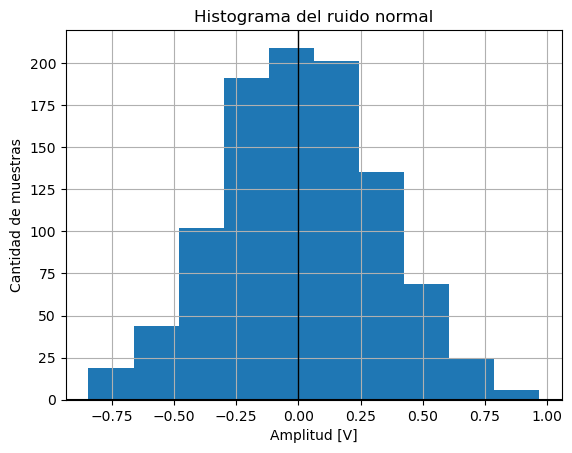

In [12]:
plt.figure(5)
plt.hist(x3)
plt.title("Histograma del ruido normal")
plt.xlabel("Amplitud [V]")
plt.ylabel("Cantidad de muestras")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Como siguiente paso, calculamos la FFT y la graficamos.

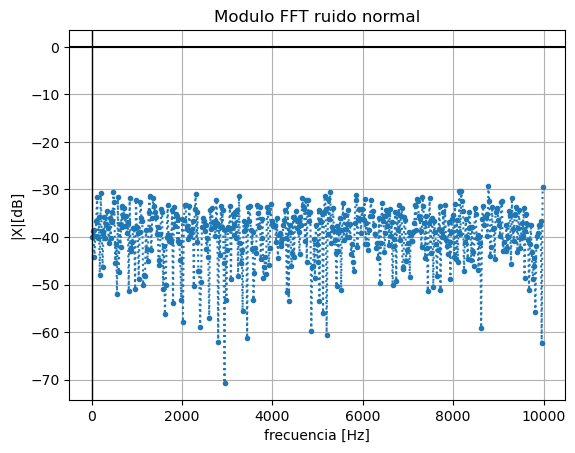

In [13]:
x3_fft = fft(x3)
x3_fft = x3_fft[:N//2]

x3_fft_abs = np.abs(x3_fft)
x3_fft_db = 20 * np.log10(x3_fft_abs / ref)

plt.figure(6)
plt.plot(freq,x3_fft_db,":.")
plt.title("Modulo FFT ruido normal")
plt.ylabel("|X|[dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Podemos apreciar que no se observa ninguna componente de frecuencia dominante, si no que la potencia se encuentra distribuida a lo largo de todo el espectro con variaciones aleatorias en su magnitud. Esto pareciera concordar con ruido blanco,

## Análisis ruido uniforme con potencia de 0.1W y media 0
Nuevamente, arrancamos el análisis como en el punto anterior, buscando en la documentación como funciona la función np.random.uniform. En la misma podemos ver que contamos con tres parametros:
- **low:** Extremo inferior del intervalo de salida (lo que llamamos a).
- **high:** Extremo superior del intervalo de salida (lo que llamamos b).
- **size:**  Tamaño del vector resultante.
Recordando algunas fórmulas de una distribución uniforme tenemos:
\begin{equation}
E_{(x)} = \frac{a+b}{2} \land V_{(x)}=\frac{(b-a)^2}{12}
\end{equation}
Reemplazando por lo que buscamos tendremos que:
\begin{equation}
E_{(x)} = \frac{a+b}{2} = 0  => a = -b
\end{equation}
\begin{equation}
V_{(x)}=\frac{(b-a)^2}{12} = 0.1 => \frac{(b-(-b))^2}{12} = 0.1 => (2b)^2 = 1.2 => b = \frac{\sqrt{1.2}}{2}
\end{equation}
\begin{equation}
b = \frac{\sqrt{1.2}}{2} \land a = -\frac{\sqrt{1.2}}{2}
\end{equation}

In [14]:
t4 = t1
x4 = np.random.uniform(low=-np.sqrt(1.2)/2,high=np.sqrt(1.2)/2,size=len(t4))

pot_x4 = np.var(x4)
print(pot_x4)

0.09536008050850851


Realizamos una vez mas su histograma, esperando encontrarnos algo similar a que para todos los valores del eje x la altura de la barra sea aproximadamente la misma, es decir, uniforme.

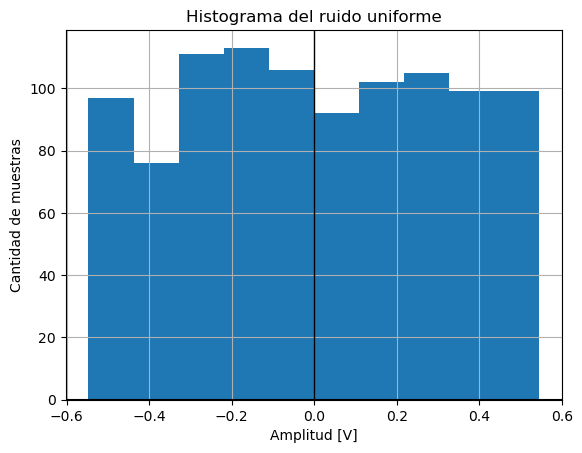

In [15]:
plt.figure(7)
plt.hist(x4)
plt.title("Histograma del ruido uniforme")
plt.xlabel("Amplitud [V]")
plt.ylabel("Cantidad de muestras")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Ahora que ya estamos seguros que nos encontramos frente a una señal de ruido uniforme, potencia 0.1 W y media 0 procedemos a realizar su FFT.

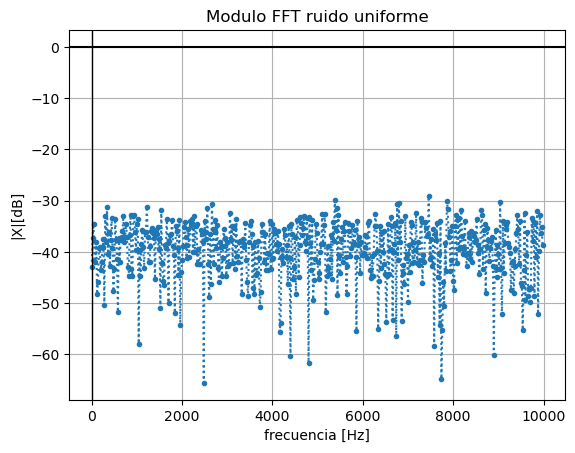

In [16]:
x4_fft = fft(x4)
x4_fft = x4_fft[:N//2]

x4_fft_abs = np.abs(x4_fft)
x4_fft_db = 20 * np.log10(x4_fft_abs / ref)

plt.figure(8)
plt.plot(freq,x4_fft_db,":.")
plt.title("Modulo FFT ruido uniforme")
plt.ylabel("|X|[dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Podemos ver como este resultado difiere muy levemente de lo ocurrido con la señal de ruido normal. Nuevamente, nos encontramos con que ninguna frecuencia destaca, si no que en todo el espectro toma valores aleatorios y la potencia de distribuye.

## Análisis pulso rectangular con frecuencia 2kHz, 1W de potencia y DutyCycle de 50%
Llegando a la última señal que analizamos, nos encontramos con una señal de pulsos rectangulares que debemos generar mediante scipy.signal.square(). Esta función tiene solamente dos argumentos, el tiempo y el duty. Para lograr generar que la frecuencia de esta señal sea la deseada debemos enviar como parametro en el tiempo $2*\pi*2000*t$.

Ahora, esta función nos devuelve una cuadrada que oscila entre 1 y -1, pero los pulsos rectangulares deben oscilar entre su amplitud y 0. Para esto hacemos $x = \frac{(square+1)}{2}$ lo cual hará que la salida oscile entre 0 y 1.

Por último, para darle la potencia deseada debemos utilizar la definición de la misma una última vez:
\begin{equation}
P = \frac{1}{N} * \sum_{k=0}^{N-1} |x_{[k]}|^2
\end{equation}
Entonces, si $x$ es una cuadrada de duty=50% tendremos que:
\begin{equation}
P = \frac{1}{N} * (\sum_{k=0}^{N/2-1}A^2 + \sum_{k=N/2}^{N-1}0) = \frac{1}{N} * A^2 * \frac{N}{2} = \frac{A^2}{2}
\end{equation}
Reemplazando P = 1W
\begin{equation}
P = \frac{A^2}{2} = 1W => A = \sqrt{2W}
\end{equation}
Para realizar la comprobación en python, esta vez no podemos utilizar la aproximación de la varianza debido a que la media no es cero si no $\frac{A}{2}$. En cambio, lo obtendremos mediante la otra definición:
\begin{equation}
P_x \approx mean(x^2)
\end{equation}

In [17]:
t5 = t1
x5 = (sp.signal.square(2*np.pi*2000*t5,duty=0.5)+1)*np.sqrt(2)/2

pot_x5 = np.mean(x5**2)

print(pot_x5)

1.0380000000000003


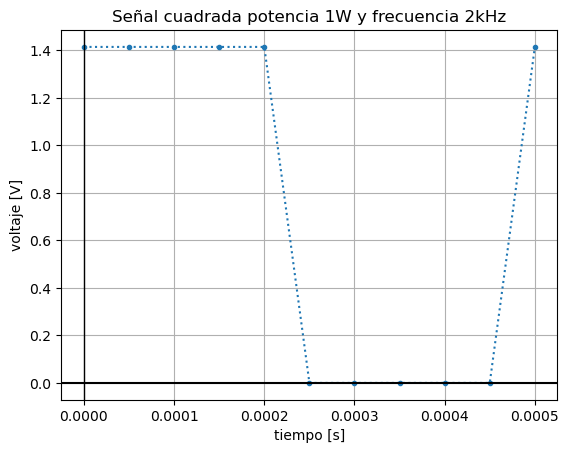

In [18]:
plt.figure(9)
plt.plot(t5[:11], x5[:11], ":.")
plt.title("Señal cuadrada potencia 1W y frecuencia 2kHz")
plt.xlabel("tiempo [s]")
plt.ylabel("voltaje [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Una vez comprobamos que la señal generada fue efectivamente una de pulsos rectangulares que la mitad de tiempo vale A y la otra mitad 0 con la frecuencia deseada y 10 puntos por periodo, pasamos a calcularle la FFT.

Idealmente, deberíamos observar deltas pero no únicamente en la frecuencia de la señal como se da en el caso del seno. Si recordamos las series de Fourier, una señal cuadrada se puede componer mediante una suma infinita de senos. Que sea una suma de senos y no de senos y cosenos se debe a que la parte oscilatoria de la función es impar, por lo cuál se proyectara a la perfección con los senos y no lo hará con los cosenos. Por lo cuál esperamos ver que se comporte como una señal continua con senos de distintas frecuencia, las cuales serán múltiplos impares de la fundamenta ff=2000 Hz. Esto traducido a FFT se debería ver como un $\delta$ en 0 Hz de mayor amplitud y deltas sucesivos cada (2n+1)*ff cada vez de menos amplitud. En nuestro gráfico, como solo se cubre hasta 10 kHz sin incluirlo, veremos entonces deltas en ff= 0 Hz, 2kHz y 6kHz.

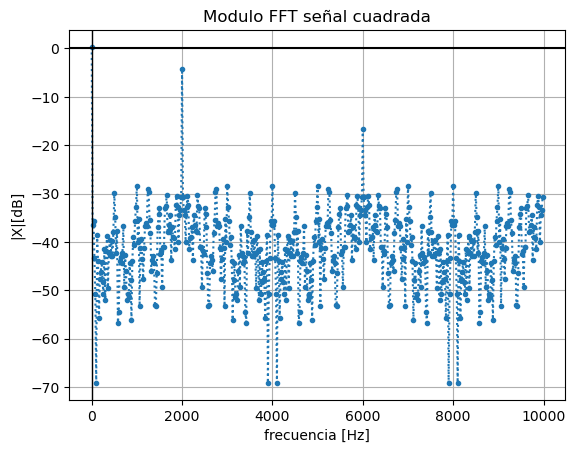

In [19]:
x5_fft = fft(x5)
x5_fft = x5_fft[:N//2]

x5_fft_abs = np.abs(x5_fft)
x5_fft_db = 20 * np.log10(x5_fft_abs/ref)

plt.figure(10)
plt.plot(freq,x5_fft_db,":.")
plt.title("Modulo FFT señal cuadrada")
plt.ylabel("|X|[dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

In [20]:
print("Magnitud en dB en 0Hz: ",x5_fft_db[freq==0])
print("Magnitud en dB en 2 kHz: ",x5_fft_db[freq==2000])
print("Magnitud en dB en 6 kHz: ",x5_fft_db[freq==6000])

Magnitud en dB en 0Hz:  [0.32394707]
Magnitud en dB en 2 kHz:  [-4.21377477]
Magnitud en dB en 6 kHz:  [-16.73365934]


Se cumplió lo que esperábamos que suceda, sin embargo llama la atención la presencia de algo similar a un ruido uniforme el cuál se encuentra muy cercano a las magnitudes de los deltas. Investigando al respecto se halló que esto podía ser debido a que algunos valores de x5 se tomaran justo durante la transición entre high y low, generando así que el valor tomado sea una indeterminación. En consecuencia la solución que encontramos para esto es agregarle una fase prácticamente imperceptible a la señal de $10^{-13}$ para evitar este error y ver que sucedía.

In [21]:
x5_mod = (sp.signal.square(2*np.pi*2000*t5+1e-13,duty=0.5)+1)*np.sqrt(2)/2

pot_x5_mod = np.mean(x5_mod**2)

print(pot_x5_mod)

1.0000000000000002


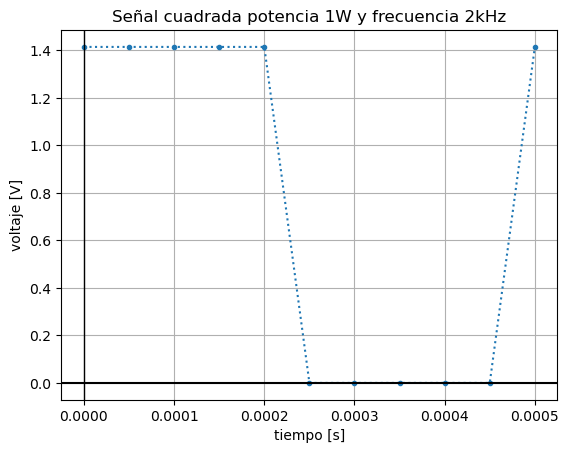

In [22]:
plt.figure(9)
plt.plot(t5[:11], x5_mod[:11], ":.")
plt.title("Señal cuadrada potencia 1W y frecuencia 2kHz")
plt.xlabel("tiempo [s]")
plt.ylabel("voltaje [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Podemos ver que la señal en sí no sufrió ningún cambio perceptible a simple vista. Ahora comprobemos que pasa con la FFT.

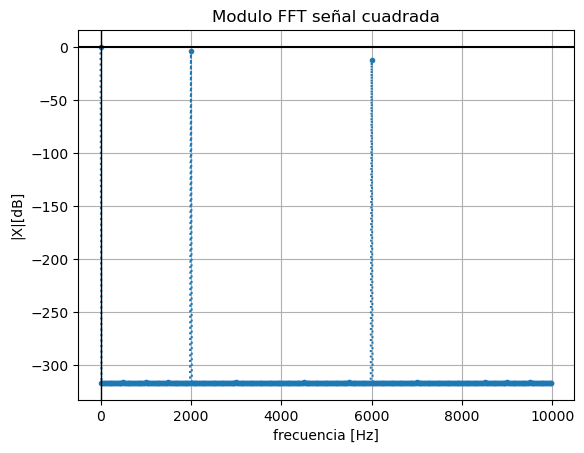

In [23]:
x5_mod_fft = fft(x5_mod)
x5_mod_fft = x5_mod_fft[:N//2]

x5_mod_fft_abs = np.abs(x5_mod_fft)
x5_mod_fft_db = 20 * np.log10((x5_mod_fft_abs+1e-13)/ref)

plt.figure(10)
plt.plot(freq,x5_mod_fft_db,":.")
plt.title("Modulo FFT señal cuadrada")
plt.ylabel("|X|[dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

In [24]:
print("Magnitud en dB en 0Hz: ",x5_mod_fft_db[freq==0])
print("Magnitud en dB en 2 kHz: ",x5_mod_fft_db[freq==2000])
print("Magnitud en dB en 6 kHz: ",x5_mod_fft_db[freq==6000])

Magnitud en dB en 0Hz:  [-9.64327467e-16]
Magnitud en dB en 2 kHz:  [-3.77904737]
Magnitud en dB en 6 kHz:  [-12.13855298]


Podemos ver que, ahora sí, se aprecia mejor lo que esperábamos ver teóricamente. tenemos 3 deltas ubicados exactamente a 0 Hz, 2kHz y 6kHz con amplitudes descendientes. Lo que podemos ver es que la potencia total de la señal estará distribuida entre todas las deltas. Si bien en 0Hz vemos 0dB en este caso no debemos asociar directamente amplitud con potencia, ya que al no tener un par simétrico de la forma +f -f, esta componente tendrá en verdad una potencia igual a la mitad que si usuramos la conversión que veníamos realizando. Esto no sucederá en los armónicos, ya que estos si son senos. Es decir:

In [25]:
print("Potencia en 0Hz: ", np.pow(10,x5_mod_fft_db[freq==0]/10)/2)
print("Potencia en 2kHz: ", np.pow(10,x5_mod_fft_db[freq==2000]/10))
print("Potencia en 6kHz: ", np.pow(10,x5_mod_fft_db[freq==6000]/10))

Potencia en 0Hz:  [0.5]
Potencia en 2kHz:  [0.41888544]
Potencia en 6kHz:  [0.06111456]


Y  como podemos ver, la suma de estas potencias se aproxima a 1W. Mientras mas armónicos tengamos, mas cercano sería el valor de la suma a la potencia total de la cuadrada.

#Conclusiones
A lo largo de este trabajo pudimos visualizar como los distintos parámetros de una señal se manifiesta en el dominio de la frecuencia, modificando la FFT. Por ejemplo en el caso de senoidales:
- **Amplitud o Potencia:** Modifica la amplitud de las $\delta$.
- **ff:** Modifica a qué frecuencia se hallarán las $\delta$.
- **fs:** Con N fijo, modifica la resolución espectral.
- **dc:** Agrega un delta en ff=0 Hz asociada al valor medio de la señal.

Utilizamos una escala en dB tomando el máximo de la FFT de la primer senoidal como 0 de referencia para poder comparar las distintas señales.
Continuando con ambos ruidos se presentaron comportamientos hasta cierto punto aleatorios, ya que no existen frecuencias dominantes si no que la potencia se distribuye a lo largo de todo el espectro. A pesar de sus diferencias en el dominio temporal, comparando su comportamiento en el dominio de frecuencias ambos ruidos son prácticamente indistinguibles.
Por último, con la señal de pulsos rectangulares pudimos ver como ciertas señales periódicas se componen mediante la sumatoria de una componente continua y varios armónicos senoidales, donde la potencia total se distribuye en todos estos.